In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask
import zarr
import xarray as xr
import cftime
import os

In [3]:
# ============== LOAD LLC ==============
llc_path = '/orcd/data/abodner/002/cody/LLC_patch/LLC4320_face1_i2880-3600_j720-1440.zarr'
llc_patch_full = xr.open_dataset(llc_path, consolidated=True)

# ============== LOAD EMULATORS ==============
# Add or remove entries here to control how many emulators are compared
emulator_configs = [
    # {
    #     'name': 'exp_0_epoch6',
    #     'key': 'emulator_1',
    #     'path': '/orcd/data/abodner/002/cody/inference_patch/multi_epoch_tests_4-25-26/2026-04-27-eval:Samudra_LLC:config_tests_experiment_6_epoch6/predictions_4d.zarr',
    #     'desc': 'exp_0_epoch6'
    # },
    # {
    #     'name': 'exp_0_epoch8',
    #     'key': 'emulator_2',
    #     'path': '/orcd/data/abodner/002/cody/inference_patch/res_2_4-29-26/2026-04-29-eval:Samudra_LLC:res_experiment_0_epoch8/predictions_4d.zarr',
    #     'desc': 'exp_0_epoch8'
    # },
    {
        'name': '72_hr_replication_test',
        'key': 'emulator_1',
        'path': '/orcd/data/abodner/002/cody/inference_patch/2026-05-2-eval:Samudra_LLC:replication_data-stride-72/predictions_4d.zarr',
        'desc': '72_hr_replication_test'
    },
    # {
    #     'name': 'exp_2_epoch8',
    #     'key': 'emulator_4',
    #     'path': '/orcd/data/abodner/002/cody/inference_patch/res_2_4-29-26/2026-04-29-eval:Samudra_LLC:res_experiment_2_epoch8/predictions_4d.zarr',
    #     'desc': 'exp_2_epoch8'
    # },
    # {
    #     'name': 'exp_3_epoch8',
    #     'key': 'emulator_5',
    #     'path': '/orcd/data/abodner/002/cody/inference_patch/res_2_4-29-26/2026-04-29-eval:Samudra_LLC:res_experiment_3_epoch8/predictions_4d.zarr',
    #     'desc': 'exp_3_epoch8'
    # },
    # {
    #     'name': 'exp_4_epoch8',
    #     'key': 'emulator_2',
    #     'path': '/orcd/data/abodner/002/cody/inference_patch/res_2_4-29-26/2026-04-29-eval:Samudra_LLC:res_experiment_4_epoch8/predictions_4d.zarr',
    #     'desc': 'exp_4_epoch8'
    # },
]

# ============== OPEN EMULATOR DATASETS ==============
emulator_patches_raw = {}
for cfg in emulator_configs:
    emulator_patches_raw[cfg['key']] = xr.open_dataset(cfg['path'], consolidated=True)
    print(f"Loaded {cfg['name']}: {cfg['desc']}")

# ============== TIME MATCHING ==============
# Use first emulator's times as reference
first_key = emulator_configs[0]['key']
emulator_times = emulator_patches_raw[first_key].time.values
matching_times = pd.DatetimeIndex([
    pd.Timestamp(t.year, t.month, t.day, t.hour, t.minute, t.second)
    for t in emulator_times
])

llc_patch = llc_patch_full.sel(time=matching_times)
print(f"LLC subset to {len(matching_times)} matching times")

# ============== PORT GRID VARS & BUILD UNIFIED STRUCTURE ==============
grid_vars = ['XC', 'YC', 'rA', 'Z']

emulator_patches = {}
for cfg in emulator_configs:
    patch = emulator_patches_raw[cfg['key']]
    for gv in grid_vars:
        patch[gv] = llc_patch[gv]
    emulator_patches[cfg['key']] = patch

# ============== UNIFIED REFERENCE LISTS ==============
# This is what all plotting scripts will use
emulator_info = [(cfg['name'], cfg['key']) for cfg in emulator_configs]
n_emulators = len(emulator_info)

all_patches = {'llc': llc_patch}
all_patches.update(emulator_patches)

print(f"\n=== Setup complete: LLC + {n_emulators} emulators ===")
for name, key in emulator_info:
    print(f"  {name} ({key})")

Loaded 72_hr_replication_test: 72_hr_replication_test
LLC subset to 6 matching times

=== Setup complete: LLC + 1 emulators ===
  72_hr_replication_test (emulator_1)


Generating normalized error-vs-time plot for Theta...


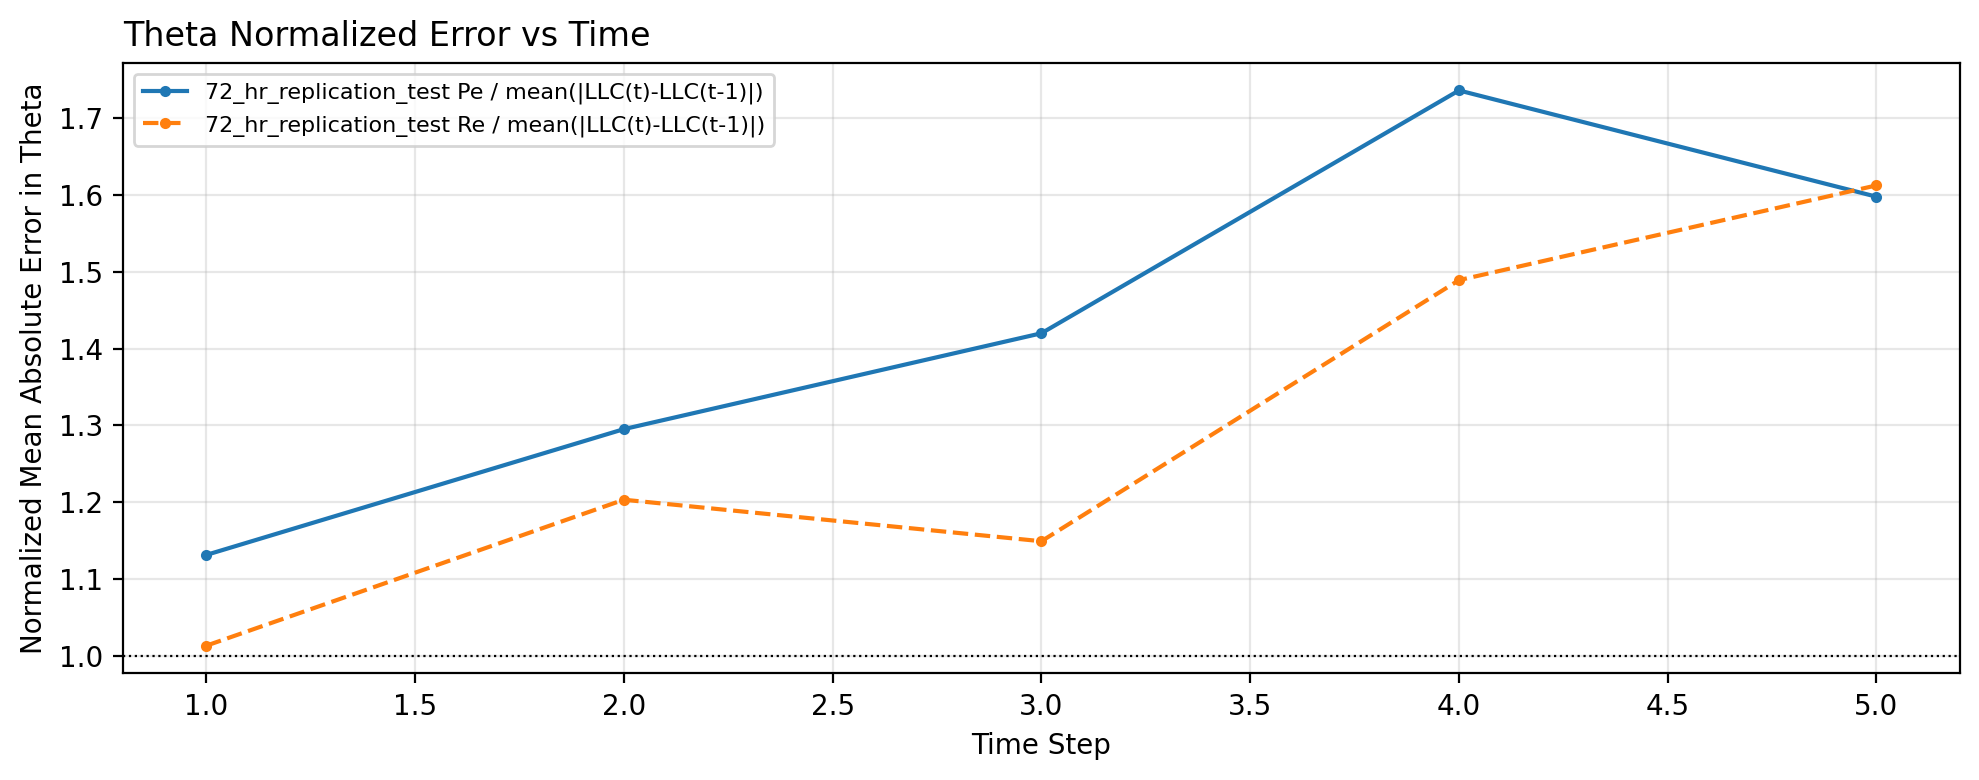

Generating normalized error-vs-time plot for Salt...


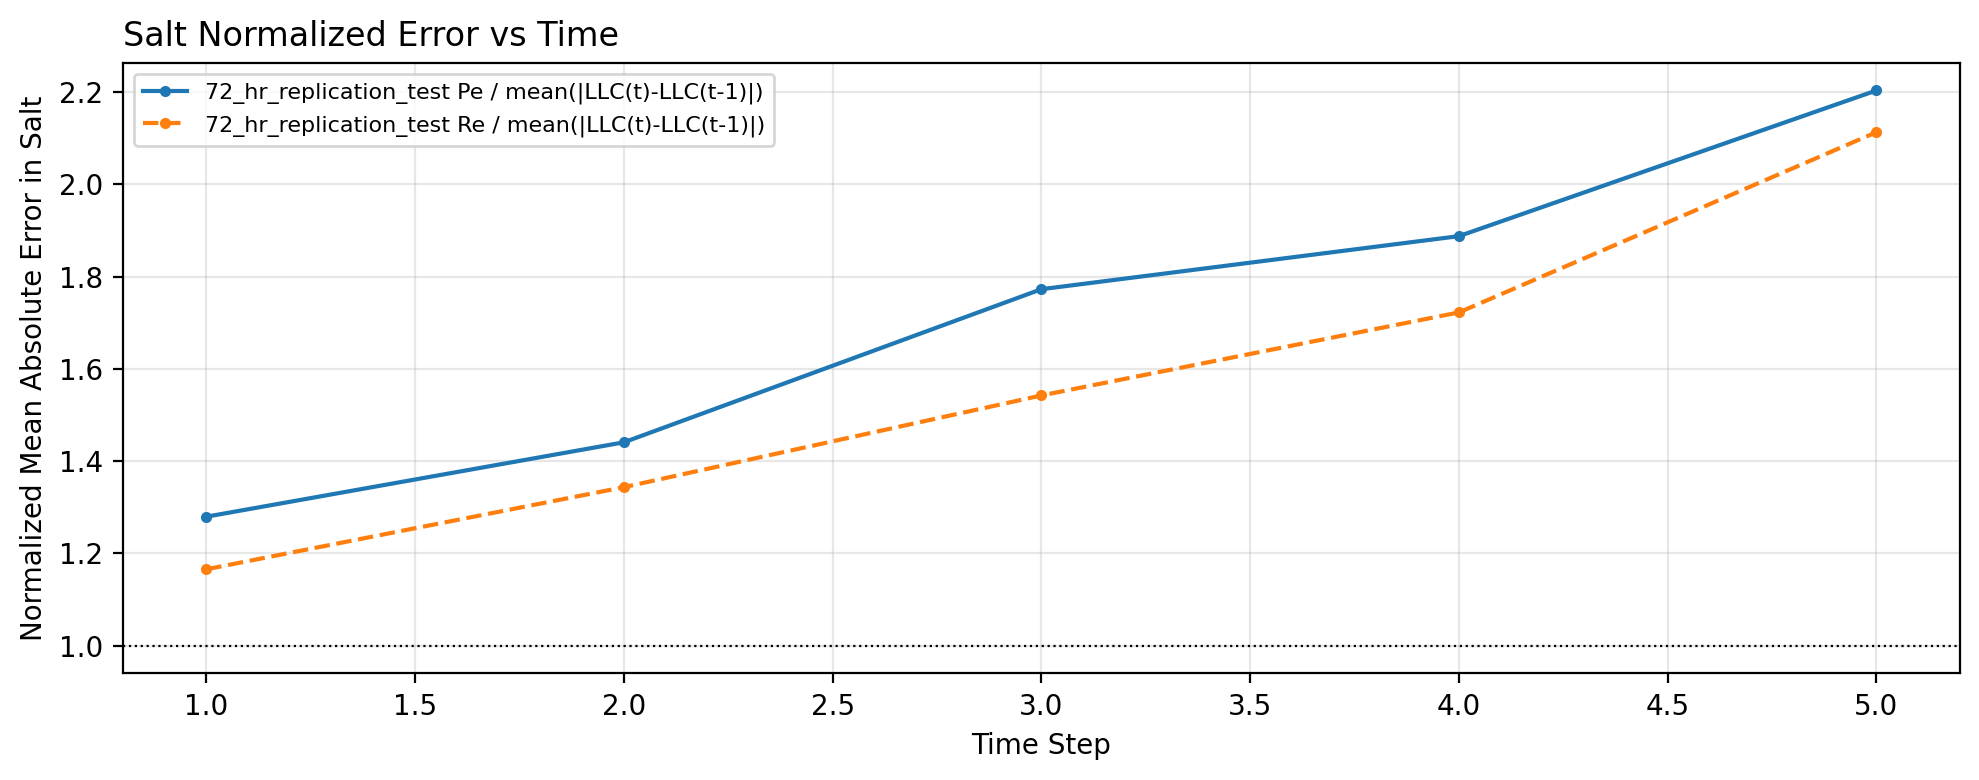

Generating normalized error-vs-time plot for U...


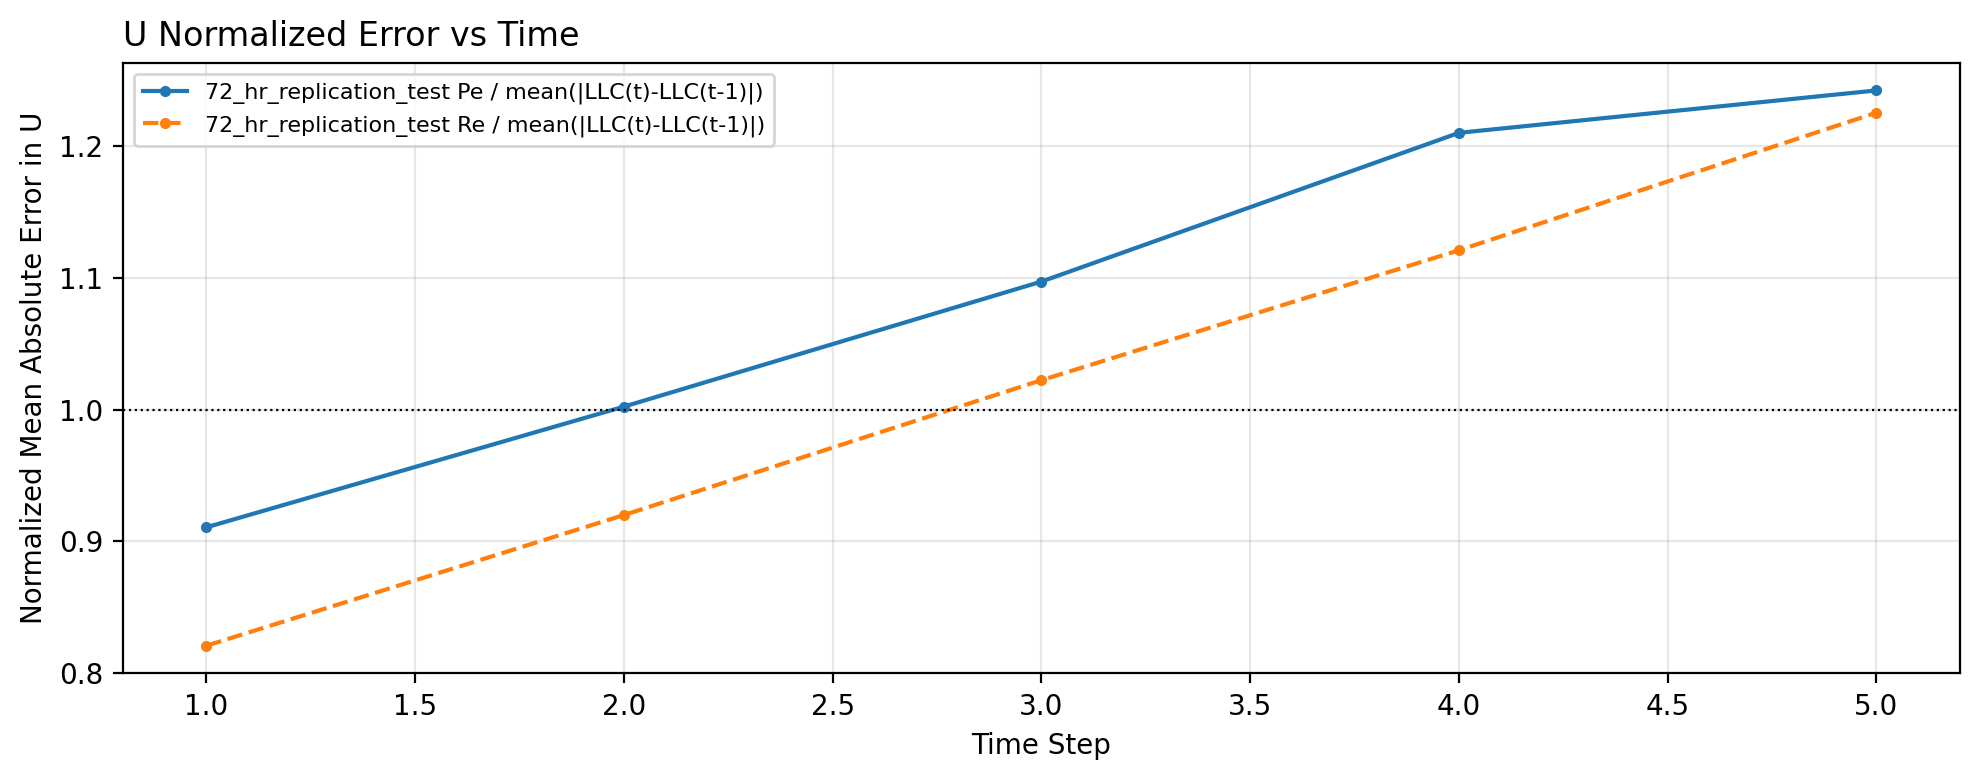

Generating normalized error-vs-time plot for V...


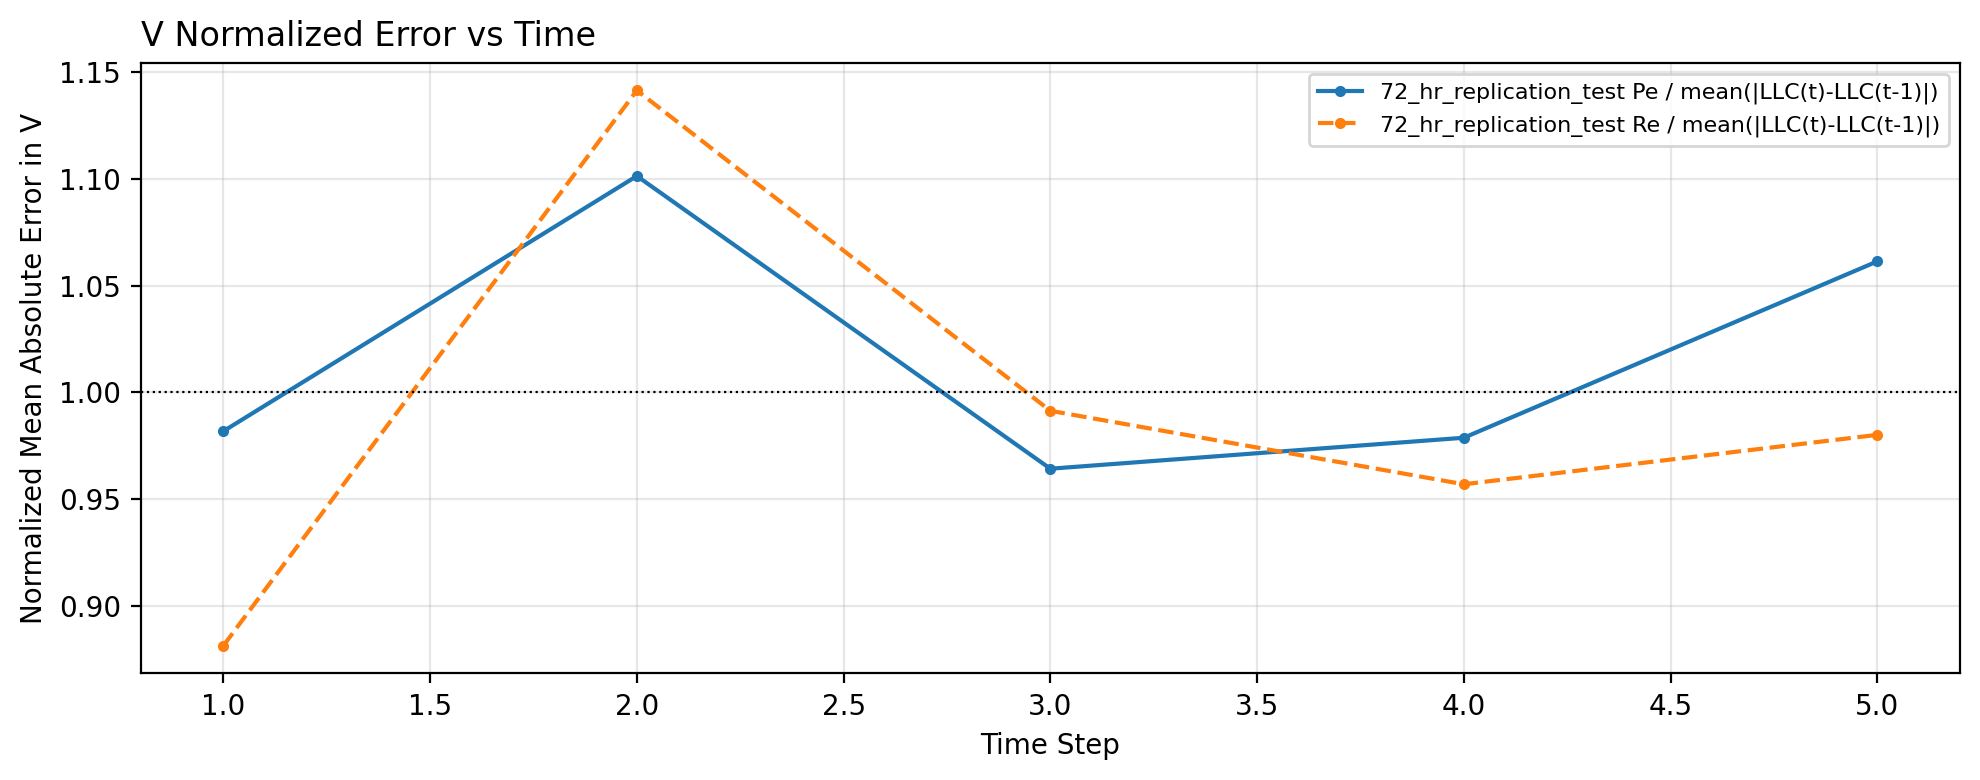

In [4]:
vars = ['Theta','Salt','U','V']

for var in vars:
    print(f"Generating normalized error-vs-time plot for {var}...")

    n_times = len(llc_patch.time)
    time_indices = np.arange(1, n_times)

    fig, ax = plt.subplots(figsize=(10, 4), dpi=200)

    for emu_name, emu_key in emulator_info:
        emulator_patch = emulator_patches[emu_key]

        prediction_errors_norm = []
        replication_errors_norm = []

        for t in time_indices:
            t1 = llc_patch[var].isel(time=t-1, k=0).to_numpy()
            t2 = llc_patch[var].isel(time=t, k=0).to_numpy()
            E2 = emulator_patch[var].isel(time=t, k=0).to_numpy()

            # baseline = natural LLC one-step change
            baseline = np.nanmean(np.abs(t2 - t1))

            # Pe = prediction error = mean(|LLC(t) - E(t)|)
            Pe = np.nanmean(np.abs(t2 - E2))

            # Re = replication error = mean(|LLC(t-1) - E(t)|)
            Re = np.nanmean(np.abs(t1 - E2))

            if baseline == 0 or np.isnan(baseline):
                Pe_norm = np.nan
                Re_norm = np.nan
            else:
                Pe_norm = Pe / baseline
                Re_norm = Re / baseline

            prediction_errors_norm.append(Pe_norm)
            replication_errors_norm.append(Re_norm)

        ax.plot(time_indices, prediction_errors_norm, marker='o', linewidth=1.5, markersize=3,
                label=f'{emu_name} Pe / mean(|LLC(t)-LLC(t-1)|)')

        ax.plot(time_indices, replication_errors_norm, marker='o', linewidth=1.5, markersize=3,
                linestyle='--',
                label=f'{emu_name} Re / mean(|LLC(t)-LLC(t-1)|)')

    ax.axhline(1, color='k', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Time Step')
    ax.set_ylabel(f'Normalized Mean Absolute Error in {var}')
    ax.set_title(f'{var} Normalized Error vs Time', loc='left', fontweight='bold')

    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

Generating depth-averaged normalized error-vs-time plot for Theta...


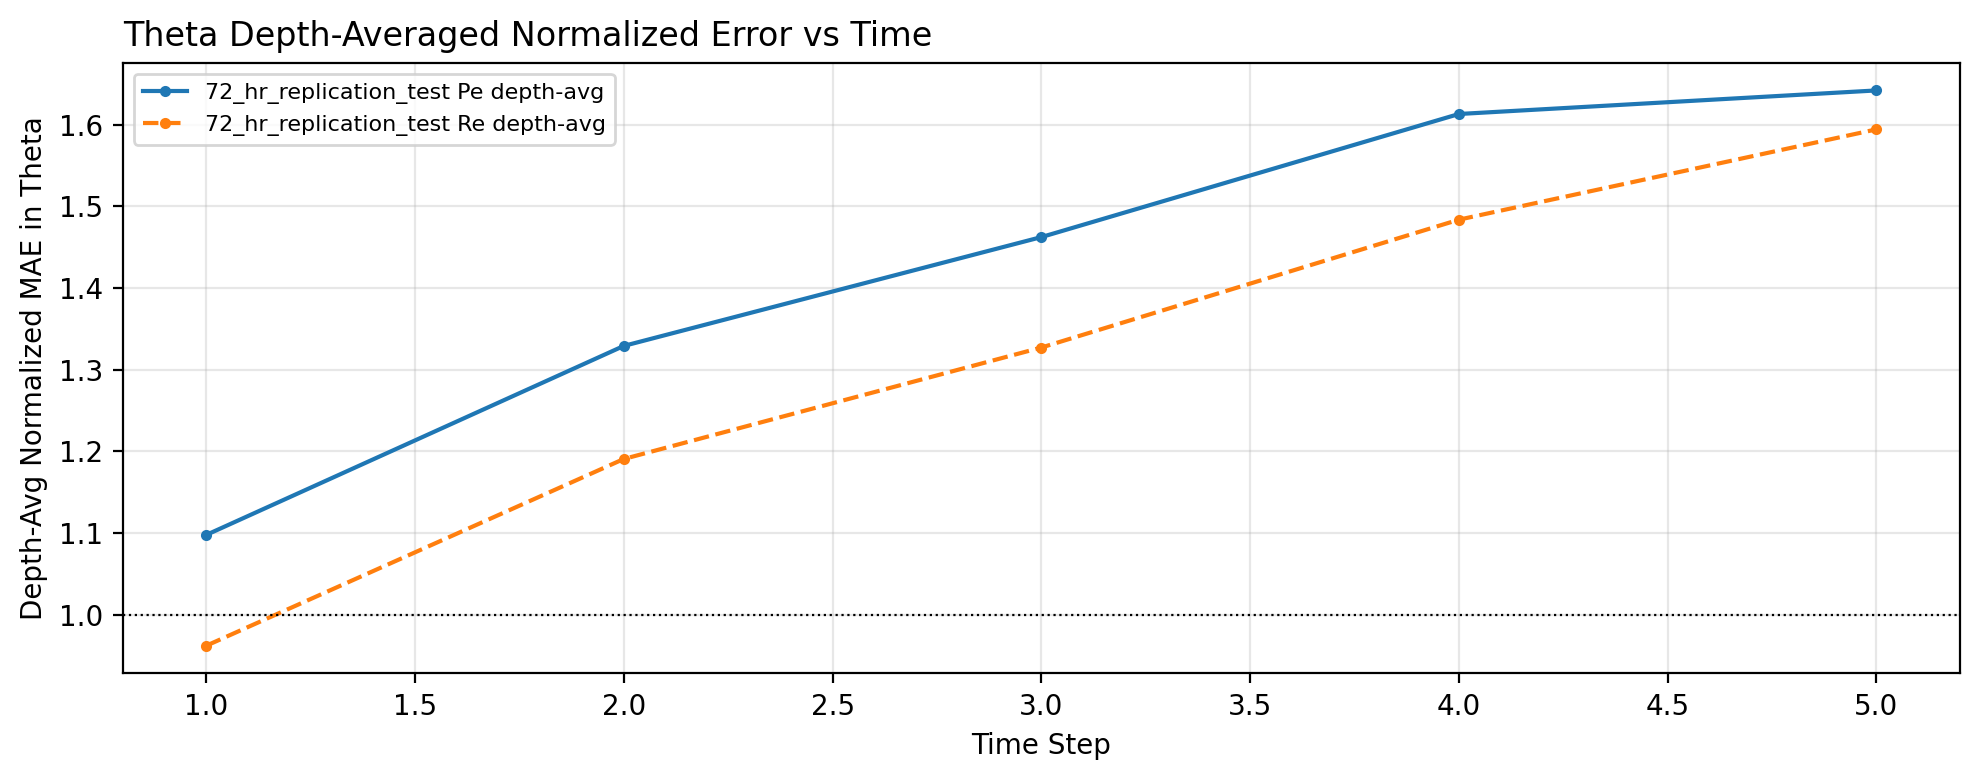

Generating depth-averaged normalized error-vs-time plot for Salt...


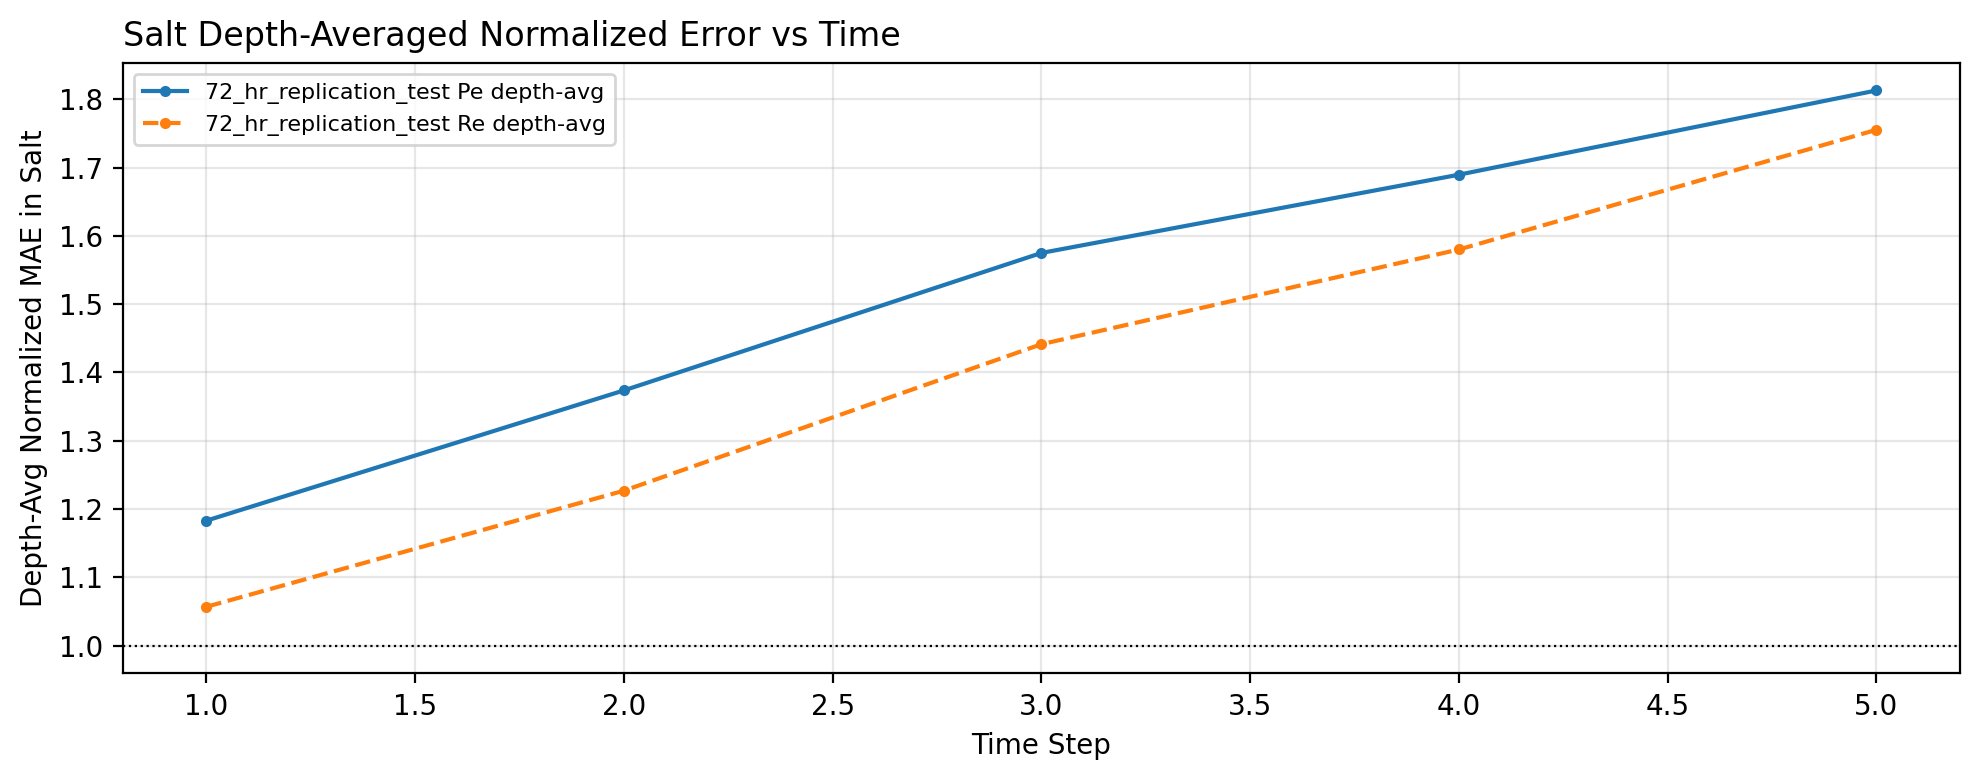

Generating depth-averaged normalized error-vs-time plot for U...


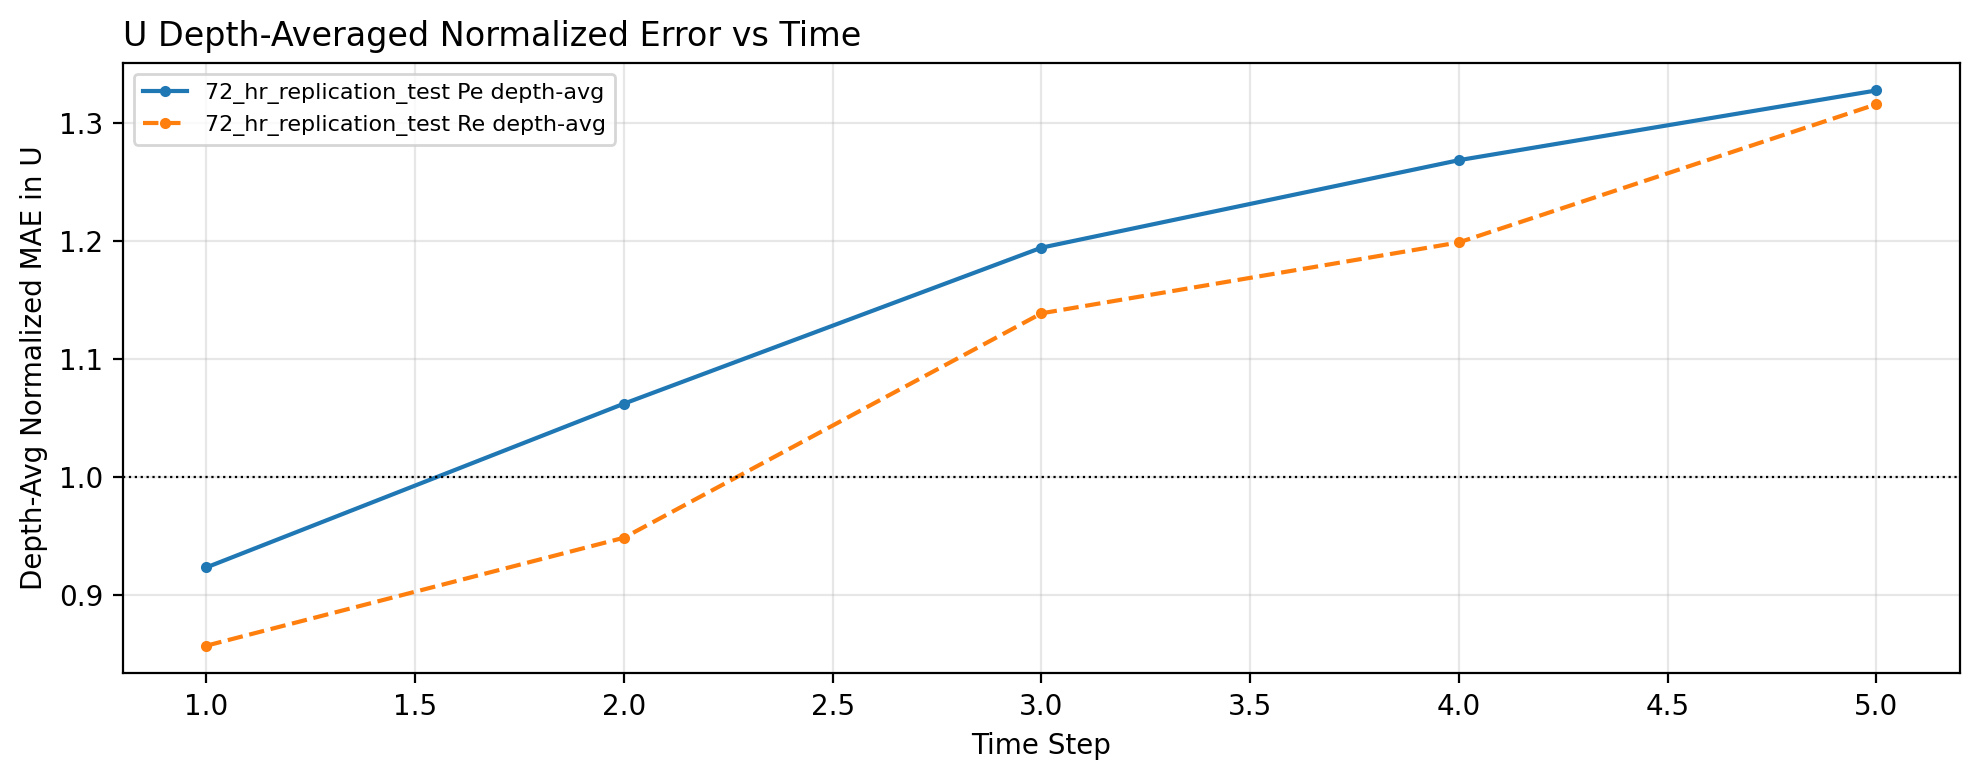

Generating depth-averaged normalized error-vs-time plot for V...


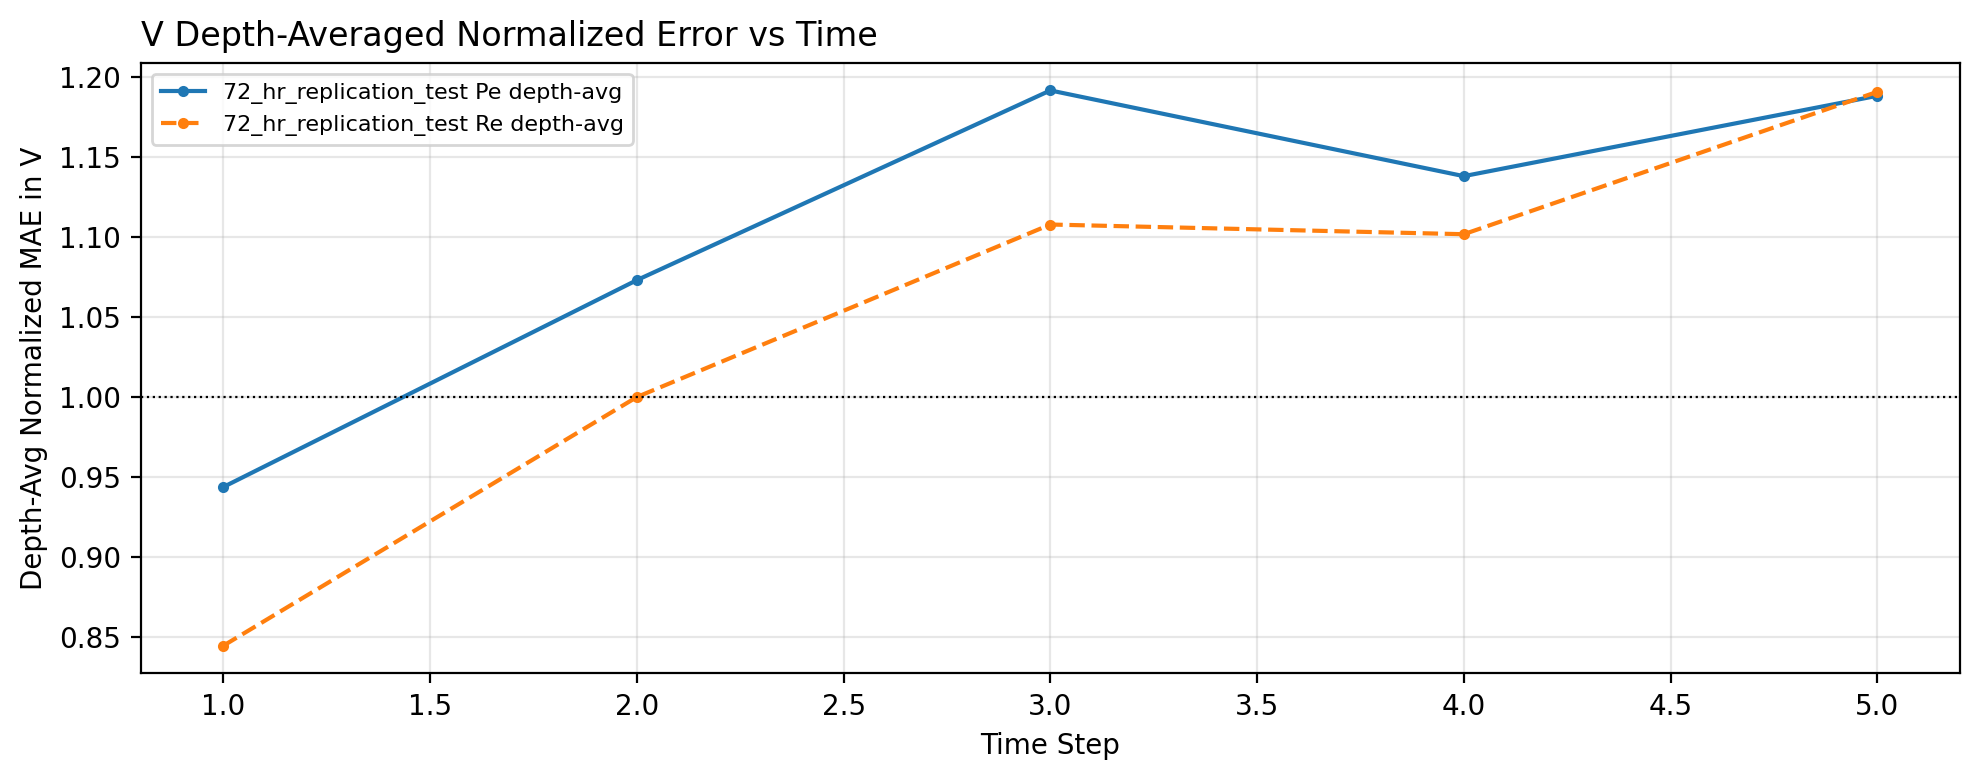

In [5]:
vars = ['Theta','Salt','U','V']

for var in vars:
    print(f"Generating depth-averaged normalized error-vs-time plot for {var}...")

    n_times = len(llc_patch.time)
    time_indices = np.arange(1, n_times)

    fig, ax = plt.subplots(figsize=(10, 4), dpi=200)

    for emu_name, emu_key in emulator_info:
        emulator_patch = emulator_patches[emu_key]

        prediction_errors_norm = []
        replication_errors_norm = []

        for t in time_indices:
            t1 = llc_patch[var].isel(time=t-1, k=slice(0, 51)).to_numpy()
            t2 = llc_patch[var].isel(time=t, k=slice(0, 51)).to_numpy()
            E2 = emulator_patch[var].isel(time=t, k=slice(0, 51)).to_numpy()

            # baseline per k = mean(|LLC(t) - LLC(t-1)|) over i/j at each depth
            baseline_k = np.nanmean(np.abs(t2 - t1), axis=(-2, -1))

            # Pe per k = mean(|LLC(t) - E(t)|) over i/j at each depth
            Pe_k = np.nanmean(np.abs(t2 - E2), axis=(-2, -1))

            # Re per k = mean(|LLC(t-1) - E(t)|) over i/j at each depth
            Re_k = np.nanmean(np.abs(t1 - E2), axis=(-2, -1))

            # normalize at each k first
            Pe_norm_k = np.where(
                (baseline_k == 0) | np.isnan(baseline_k),
                np.nan,
                Pe_k / baseline_k
            )

            Re_norm_k = np.where(
                (baseline_k == 0) | np.isnan(baseline_k),
                np.nan,
                Re_k / baseline_k
            )

            # depth-wise average of normalized errors
            Pe_norm = np.nanmean(Pe_norm_k)
            Re_norm = np.nanmean(Re_norm_k)

            prediction_errors_norm.append(Pe_norm)
            replication_errors_norm.append(Re_norm)

        ax.plot(time_indices, prediction_errors_norm, marker='o', linewidth=1.5, markersize=3,
                label=f'{emu_name} Pe depth-avg')

        ax.plot(time_indices, replication_errors_norm, marker='o', linewidth=1.5, markersize=3,
                linestyle='--',
                label=f'{emu_name} Re depth-avg')

    ax.axhline(1, color='k', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Time Step')
    ax.set_ylabel(f'Depth-Avg Normalized MAE in {var}')
    ax.set_title(f'{var} Depth-Averaged Normalized Error vs Time', loc='left', fontweight='bold')

    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()